In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

# Para ver los gráficos en el Notebook
%matplotlib inline

# Opcional: Si quieres que los gráficos no se guarden solo en archivo
# import matplotlib
# matplotlib.use("Agg") 

print("Librerías cargadas.")

Librerías cargadas.


In [2]:
print("\n" + "="*55)
print("  REGRESIÓN LOGÍSTICA — Bike Sharing Dataset")
print("="*55)

df = pd.read_csv("dataset.csv")

# Columnas que NO usamos como features
DROP_COLS   = ["instant", "dteday", "casual", "registered", "cnt"]
TARGET_COL  = "alta_demanda"

# Crear variable objetivo binaria
mediana_cnt = df["cnt"].median()
df[TARGET_COL] = (df["cnt"] > mediana_cnt).astype(int)

print(f"\n  Mediana de cnt     : {mediana_cnt:.0f} viajes/día")
print(f"  Clase 1 (alta dem.): {df[TARGET_COL].sum()} días")
print(f"  Clase 0 (baja dem.): {(df[TARGET_COL] == 0).sum()} días")

X = df.drop(columns=DROP_COLS + [TARGET_COL])
y = df[TARGET_COL]

FEATURE_NAMES = list(X.columns)
print(f"\n  Features usadas ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")


  REGRESIÓN LOGÍSTICA — Bike Sharing Dataset

  Mediana de cnt     : 4548 viajes/día
  Clase 1 (alta dem.): 365 días
  Clase 0 (baja dem.): 366 días

  Features usadas (11): ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n  Train: {len(X_train)} muestras  |  Test: {len(X_test)} muestras")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


  Train: 584 muestras  |  Test: 147 muestras


In [4]:
print("\n  Entrenando modelo...")
modelo = LogisticRegression(
    max_iter   = 1000,
    C          = 1.0,
    solver     = "lbfgs",
    random_state = 42
)
modelo.fit(X_train_sc, y_train)
print("  ✓ Entrenamiento completado")


  Entrenando modelo...
  ✓ Entrenamiento completado


In [5]:
y_pred  = modelo.predict(X_test_sc)
y_proba = modelo.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test,  y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test,    y_pred, zero_division=0)
f1   = f1_score(y_test,        y_pred, zero_division=0)
auc  = roc_auc_score(y_test,   y_proba)
cm   = confusion_matrix(y_test, y_pred)

print("\n" + "-"*45)
print("  MÉTRICAS EN TEST")
print("-"*45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("-"*45)
print("\n  Reporte completo:")
print(classification_report(y_test, y_pred,
      target_names=["Baja Demanda", "Alta Demanda"]))


---------------------------------------------
  MÉTRICAS EN TEST
---------------------------------------------
  Accuracy  : 0.8980  (89.80%)
  Precision : 0.8919
  Recall    : 0.9041
  F1-Score  : 0.8980
  AUC-ROC   : 0.9472
---------------------------------------------

  Reporte completo:
              precision    recall  f1-score   support

Baja Demanda       0.90      0.89      0.90        74
Alta Demanda       0.89      0.90      0.90        73

    accuracy                           0.90       147
   macro avg       0.90      0.90      0.90       147
weighted avg       0.90      0.90      0.90       147



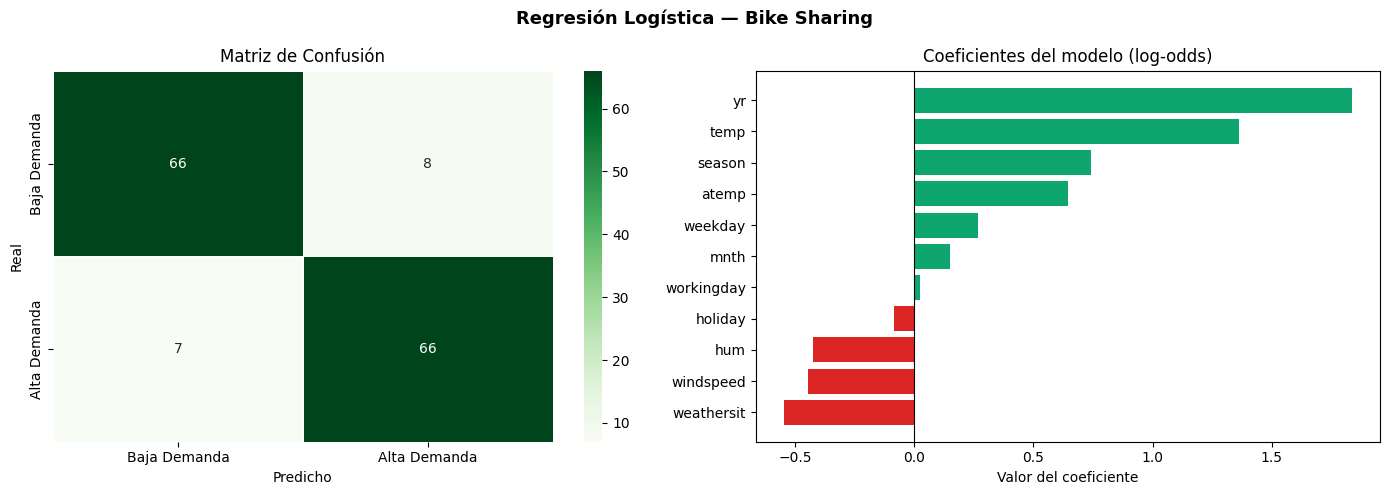


  ✓ Gráfica guardada: resultados_rl.png


<Figure size 640x480 with 0 Axes>

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Regresión Logística — Bike Sharing", fontsize=13, fontweight="bold")

# Matriz de confusión
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Baja Demanda", "Alta Demanda"],
    yticklabels=["Baja Demanda", "Alta Demanda"],
    ax=axes[0], linewidths=.5
)
axes[0].set_title("Matriz de Confusión")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

# Importancia de coeficientes
coef_df = pd.DataFrame({
    "Feature"     : FEATURE_NAMES,
    "Coeficiente" : modelo.coef_[0]
}).sort_values("Coeficiente")
axes[1].barh(coef_df["Feature"], coef_df["Coeficiente"],
             color=["#dc2626" if c < 0 else "#0ea56e" for c in coef_df["Coeficiente"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Coeficientes del modelo (log-odds)")
axes[1].set_xlabel("Valor del coeficiente")

plt.tight_layout()
plt.show() # Mostrar en el notebook
plt.savefig("resultados_rl.png", dpi=120)
print("\n  ✓ Gráfica guardada: resultados_rl.png")

In [7]:
# Guardar modelo y scaler
joblib.dump(modelo,  "modelo_rl.pkl")
joblib.dump(scaler,  "scaler_rl.pkl")

# Guardar feature_names.json
with open("feature_names.json", "w") as f:
    json.dump({
        "features"      : FEATURE_NAMES,
        "mediana_cnt"   : float(mediana_cnt),
        "target_col"    : TARGET_COL
    }, f, indent=2)

print("✓ Archivos guardados correctamente. La web ya puede usar este modelo.")

✓ Archivos guardados correctamente. La web ya puede usar este modelo.
